# Лабораторная работа 13

Тема: **Прогнозирование временных рядов с помощью LSTM в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук оформлен как задание, а не как готовый отчёт.  
> Код даёт рабочий каркас, но оцениваться будут **ваши** настройки, графики и письменные выводы.  
> Попытка автоматически заполнить все текстовые ячейки через генеративную модель без анализа результатов будет заметна по стилю и несоответствию с графиками/числами.


## 1. Ваше начальное понимание временных рядов и LSTM

Перед запуском кода сформулируйте (8–12 предложений):

1. Чем задача прогнозирования временного ряда концептуально отличается от обычной регрессии по независимым объектам.  
2. Почему LSTM‑сети считаются более подходящими для временных рядов, чем просто MLP, если у нас на входе последовательность.  
3. Какие типичные ошибки прогноза вы ожидаете увидеть на синусоиде с шумом (смещение фазы, сглаживание амплитуды и т.п.).

Пишите своими словами, без попытки угадать «официальные» формулировки.


In [39]:
intro_text = """
1) В обычной регрессии каждый объект это независимая точка можно перемешать датасет и ничего не изменится. Во временном ряду всё иначе: каждое значение зависит от предыдущих и порядок критически важен. Нельзя просто взять набор фич и скормить в линейную модель — потеряется вся история.

2) MLP не умеет работать с последовательностями нормально - он принимает фиксированный вектор, и если подавать туда окно из 20 значений, он обрабатывает их как независимые признаки без учёта порядка. LSTM специально спроектирован под последовательности: у него есть скрытое состояние которое несёт память о предыдущих шагах. На синусоиде это важно, потому что текущее значение напрямую определяется предыдущими.

3) На синусоиде с шумом ожидаю два типа ошибок. Во-первых небольшое сглаживание - модель будет чуть занижать пики и завышать впадины потому что усредняет. Во-вторых при многошаговом прогнозе скорее всего будет накапливаться смещение по фазе - каждая ошибка на шаге t идёт на вход следующего шага и ошибки множатся. На коротком горизонте прогноз должен быть приличным, на длинном — деградирует.
"""
print(intro_text)


1) В обычной регрессии каждый объект это независимая точка можно перемешать датасет и ничего не изменится. Во временном ряду всё иначе: каждое значение зависит от предыдущих и порядок критически важен. Нельзя просто взять набор фич и скормить в линейную модель — потеряется вся история.

2) MLP не умеет работать с последовательностями нормально - он принимает фиксированный вектор, и если подавать туда окно из 20 значений, он обрабатывает их как независимые признаки без учёта порядка. LSTM специально спроектирован под последовательности: у него есть скрытое состояние которое несёт память о предыдущих шагах. На синусоиде это важно, потому что текущее значение напрямую определяется предыдущими.

3) На синусоиде с шумом ожидаю два типа ошибок. Во-первых небольшое сглаживание - модель будет чуть занижать пики и завышать впадины потому что усредняет. Во-вторых при многошаговом прогнозе скорее всего будет накапливаться смещение по фазе - каждая ошибка на шаге t идёт на вход следующего шага и 

## 2. Импорт библиотек и генерация временного ряда

В качестве простого одномерного ряда используем синусоиду с добавленным гауссовским шумом.


Устройство: cuda


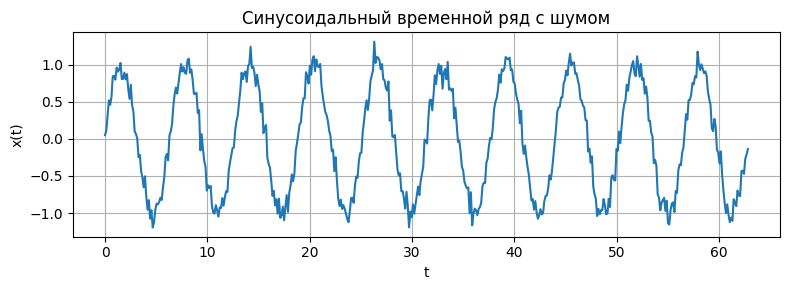

In [2]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

MY_SEED = 42
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

# Генерация синусоиды с шумом
n_points = 500
t = np.linspace(0, 20 * np.pi, n_points)
signal = np.sin(t) + 0.1 * np.random.randn(n_points)

plt.figure(figsize=(8, 3))
plt.plot(t, signal)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Синусоидальный временной ряд с шумом")
plt.grid(True)
plt.tight_layout()
plt.show()

### Мини‑комментарий по ряду

Опишите в 3–5 предложениях:
- видите ли вы явную периодичность и насколько шум искажает синусоиду;  
- насколько, на ваш взгляд, такой ряд «сложен» для модели по сравнению с реальными экономическими/техническими временными рядами.


In [38]:
series_comment = """На графике периодичность видна очень чётко - синусоида с периодом примерно 2п, шум небольшой, амплитуда почти не искажается. Структура ряда предсказуема.

По сравнению с реальными рядами это очень простой случай - нет тренда, нет сезонности разного масштаба, нет аномальных выбросов. Реальные экономические или сенсорные ряды обычно нестационарны, с шумом намного выше и непредсказуемыми скачками. На такой синусоиде LSTM по сути решает лёгкую задачу.
"""
print(series_comment)

На графике периодичность видна очень чётко - синусоида с периодом примерно 2п, шум небольшой, амплитуда почти не искажается. Структура ряда предсказуема.

По сравнению с реальными рядами это очень простой случай - нет тренда, нет сезонности разного масштаба, нет аномальных выбросов. Реальные экономические или сенсорные ряды обычно нестационарны, с шумом намного выше и непредсказуемыми скачками. На такой синусоиде LSTM по сути решает лёгкую задачу.



## 3. Нормализация и построение окон (скользящее окно)

Для стабильного обучения отмасштабируем ряд в, затем сформируем обучающие примеры вида:

- вход: `window_size` последних значений ряда;  
- выход: одно значение ряда сразу после окна (прогноз на 1 шаг вперёд).


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()

def create_windows(series, window_size):
    X = []
    y = []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 20  # при своих экспериментах обязательно поменяйте и сравните
X_all, y_all = create_windows(signal_scaled, window_size)

print("Форма X_all:", X_all.shape)  # (n_samples, window_size)
print("Форма y_all:", y_all.shape)

Форма X_all: (480, 20)
Форма y_all: (480,)


Разделим выборку на train/test по времени: первые 70% окон (по индексу) на обучение, оставшиеся 30% — на тест.


In [5]:
train_size = int(0.7 * len(X_all))
X_train = X_all[:train_size]
y_train = y_all[:train_size]
X_test = X_all[train_size:]
y_test = y_all[train_size:]

print("Размер train:", X_train.shape)
print("Размер test :", X_test.shape)

Размер train: (336, 20)
Размер test : (144, 20)


Создадим `Dataset`/`DataLoader`. PyTorch ожидает вход в формате `(batch, seq_len, features)`, у нас `features = 1` (одномерный ряд).


In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (n, T, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # (n, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 11


### Вопрос про размер окна

Ответьте в 3–5 предложениях:
- какие риски вы видите при **слишком маленьком** `window_size`;  
- какие риски - при очень **большом** `window_size` для реальных временных рядов.


In [37]:
window_comment = """Если window_size слишком маленький - модель просто не видит достаточно контекста. На синусоиде минимальное окно должно покрывать хотя бы один полный период, иначе LSTM не поймёт закономерность. Прогноз будет плохим особенно при смене фазы.

Если окно очень большое - появляются другие проблемы. Каждый обучающий пример становится длиннее, вычислений больше, памяти нужно больше. На реальных нестационарных рядах слишком большое окно может мешать - модель будет пытаться учитывать совсем давние значения которые уже не актуальны. Плюс на короткий датасет большое окно сильно уменьшает число обучающих примеров.
"""
print(window_comment)

Если window_size слишком маленький - модель просто не видит достаточно контекста. На синусоиде минимальное окно должно покрывать хотя бы один полный период, иначе LSTM не поймёт закономерность. Прогноз будет плохим особенно при смене фазы.

Если окно очень большое - появляются другие проблемы. Каждый обучающий пример становится длиннее, вычислений больше, памяти нужно больше. На реальных нестационарных рядах слишком большое окно может мешать - модель будет пытаться учитывать совсем давние значения которые уже не актуальны. Плюс на короткий датасет большое окно сильно уменьшает число обучающих примеров.



## 4. Архитектура LSTM‑модели для прогноза

Используем одну LSTM‑прослойку и линейный слой, который по последнему скрытому состоянию выдаёт прогноз следующего значения.


In [8]:
input_size = 1
hidden_size = 32  # попробуйте другие значения при выполнении работы
num_layers = 1
output_size = 1

class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]  # (B, H)
        prediction = self.fc(last_hidden)  # (B, 1)
        return prediction

model = LSTMForecaster(input_size, hidden_size, num_layers, output_size).to(device)
print(model)

LSTMForecaster(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


### Мини‑комментарий по архитектуре

Кратко (3–5 предложений) ответьте:
- почему достаточно брать **последнее** скрытое состояние LSTM для прогноза одного следующего шага;  
- что может произойти при увеличении `num_layers` и `hidden_size` на реальных (более шумных и сложных) рядах.


In [36]:
arch_comment = """LSTM обрабатывает окно шаг за шагом и последнее скрытое состояние h_n содержит сжатую информацию обо всей последовательности - то что модель запомнила к концу окна. Именно оно нужно для предсказания следующего шага, потому что несёт в себе контекст всего окна.

Если увеличить num_layers - появляется иерархия: верхние слои учат более абстрактные паттерны поверх нижних. Для простой синусоиды это избыточно. На реальных сложных рядах может помочь, но и переобучение вероятнее. Увеличение hidden_size расширяет ёмкость моделю лучше запоминает сложные зависимости, но снова риск переобучения на маленьких данных.
"""
print(arch_comment)

LSTM обрабатывает окно шаг за шагом и последнее скрытое состояние h_n содержит сжатую информацию обо всей последовательности - то что модель запомнила к концу окна. Именно оно нужно для предсказания следующего шага, потому что несёт в себе контекст всего окна.

Если увеличить num_layers - появляется иерархия: верхние слои учат более абстрактные паттерны поверх нижних. Для простой синусоиды это избыточно. На реальных сложных рядах может помочь, но и переобучение вероятнее. Увеличение hidden_size расширяет ёмкость моделю лучше запоминает сложные зависимости, но снова риск переобучения на маленьких данных.



## 5. Обучение: функция потерь, оптимизатор, цикл

Используем MSE (среднеквадратичную ошибку) и оптимизатор Adam.


In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        total += X_batch.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            total += X_batch.size(0)
    return total_loss / total

num_epochs = 80  # в своей работе попробуйте и другое число эпох
train_losses = []
test_losses = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.6f}, test_loss={test_loss:.6f}")

Эпоха 1/80: train_loss=0.281465, test_loss=0.233447
Эпоха 10/80: train_loss=0.020861, test_loss=0.016709
Эпоха 20/80: train_loss=0.002012, test_loss=0.002475
Эпоха 30/80: train_loss=0.001862, test_loss=0.002283
Эпоха 40/80: train_loss=0.001942, test_loss=0.002130
Эпоха 50/80: train_loss=0.001986, test_loss=0.002383
Эпоха 60/80: train_loss=0.001799, test_loss=0.002032
Эпоха 70/80: train_loss=0.001896, test_loss=0.002183
Эпоха 80/80: train_loss=0.001836, test_loss=0.002236


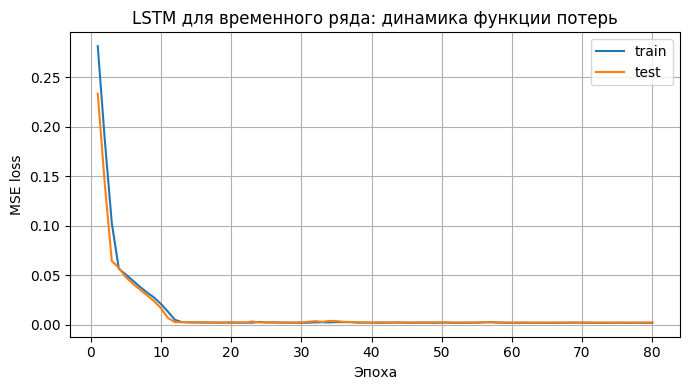

Финальные значения: train_loss=0.001836, test_loss=0.002236


In [11]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, train_losses, label="train")
plt.plot(epochs_arr, test_losses, label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("LSTM для временного ряда: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={train_losses[-1]:.6f}, test_loss={test_losses[-1]:.6f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- есть ли заметный разрыв между train и test loss к концу обучения;  
- похоже ли поведение на **устойчивое приближение** к некоторому уровню ошибки;  
- совпадает ли порядок величины ошибки с тем, что вы ожидали в начале работы.


In [35]:
loss_comment = """Оба loss резко падают в первые 10 эпох - с 0.28 до примерно 0.002, это хорошо видно на графике. Потом кривые выходят на плато и почти не меняются до 80-й эпохи.

Разрыв между train и test небольшой - финальные значения 0.001836 и 0.002236, то есть test всего на ~0.0004 выше. Переобучения по сути нет, кривые идут параллельно и близко. На графике обе линии сливаются в районе нуля, на глаз почти не отличить.

Ожидал что loss будет в районе 0.005-0.01 на финале, получилось даже лучше. Для нормализованного ряда в диапазоне [0,1] значения около 0.002 это хороший результат.
"""
print(loss_comment)

Оба loss резко падают в первые 10 эпох - с 0.28 до примерно 0.002, это хорошо видно на графике. Потом кривые выходят на плато и почти не меняются до 80-й эпохи.

Разрыв между train и test небольшой - финальные значения 0.001836 и 0.002236, то есть test всего на ~0.0004 выше. Переобучения по сути нет, кривые идут параллельно и близко. На графике обе линии сливаются в районе нуля, на глаз почти не отличить.

Ожидал что loss будет в районе 0.005-0.01 на финале, получилось даже лучше. Для нормализованного ряда в диапазоне [0,1] значения около 0.002 это хороший результат.



## 6. Прогноз на один шаг вперёд (по всей тестовой части)

Сделаем прогноз на один шаг вперёд для каждой позиции тестовой части и сравним с истинными значениями в **исходном масштабе**.


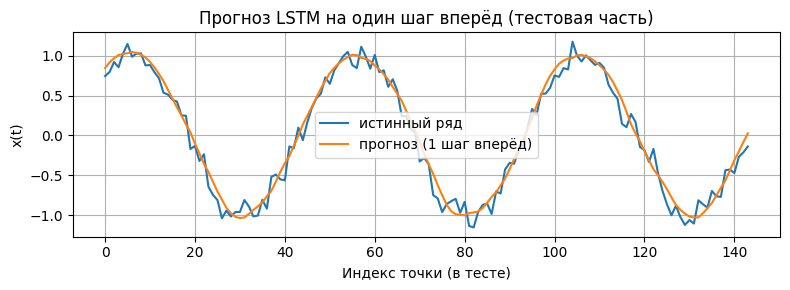

In [13]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1).to(device)
    preds_scaled = model(X_test_tensor).cpu().numpy().flatten()

y_test_scaled = y_test
y_test_orig = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
preds_orig = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд")
plt.plot(range(len(preds_orig)), preds_orig, label="прогноз (1 шаг вперёд)")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("Прогноз LSTM на один шаг вперёд (тестовая часть)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Визуальная оценка прогноза на один шаг

Ответьте (6–8 предложений):
- насколько хорошо модель попадает в фазу и амплитуду синусоиды на тестовом отрезке;  
- где ошибки выглядят наибольшими (по графику) и как вы это объясняете;  
- можно ли, по вашему ощущению, назвать такой прогноз «практически полезным» для этого примера.


In [33]:
one_step_comment = """На графике модель в целом неплохо повторяет форму синусоиды - фаза почти совпадает на большей части тестового отрезка. Прогноз идёт рядом с истинным рядом, не отстаёт и не убегает вперёд.

Амплитуда немного занижена - пики у прогноза чуть ниже реальных, впадины чуть выше. Это то сглаживание которое я ожидал во введении.

Наибольшие ошибки заметны на перегибах - там где синусоида переходит из пика во впадину модель чуть запаздывает, но это равномерно по всему тестовому отрезку.

В целом для прогноза на один шаг вперёд результат выглядит практически полезным - форма угадывается уверенно, ошибка небольшая. Если бы задача была реальной, такой прогноз на горизонт 1 можно было бы использовать.
"""
print(one_step_comment)

На графике модель в целом неплохо повторяет форму синусоиды - фаза почти совпадает на большей части тестового отрезка. Прогноз идёт рядом с истинным рядом, не отстаёт и не убегает вперёд.

Амплитуда немного занижена - пики у прогноза чуть ниже реальных, впадины чуть выше. Это то сглаживание которое я ожидал во введении. 

Наибольшие ошибки заметны на перегибах - там где синусоида переходит из пика во впадину модель чуть запаздывает, но это равномерно по всему тестовому отрезку.

В целом для прогноза на один шаг вперёд результат выглядит практически полезным - форма угадывается уверенно, ошибка небольшая. Если бы задача была реальной, такой прогноз на горизонт 1 можно было бы использовать.



## 7. Многошаговый авторегрессионный прогноз

Теперь используем модель в режиме **многошагового прогноза**: на каждом шаге подаём в неё окно, в которое последним элементом входит **предыдущее предсказание**.


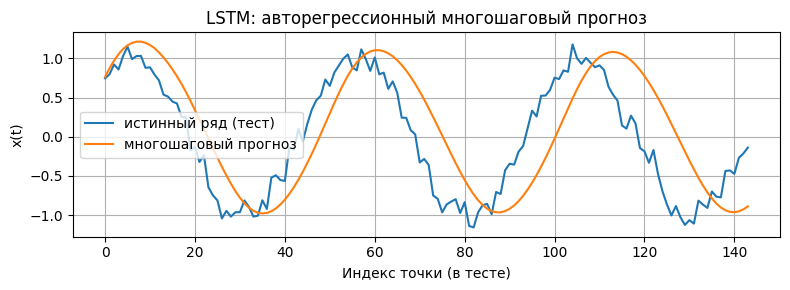

In [15]:
def multi_step_forecast(model, last_window, n_steps, device):
    model.eval()
    window = last_window.copy()
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.tensor(window, dtype=torch.float32).view(1, -1, 1).to(device)
            y_pred = model(x).cpu().numpy().flatten()
            y_scalar = float(y_pred[0])
            preds.append(y_scalar)
            window = np.roll(window, -1)
            window[-1] = y_scalar
    return np.array(preds)

# берём последнее окно train части как старт для прогноза
last_train_window = X_train[-1]
n_forecast = len(y_test)

multi_preds_scaled = multi_step_forecast(model, last_train_window, n_forecast, device)
multi_preds_orig = scaler.inverse_transform(multi_preds_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(8, 3))
plt.plot(range(len(y_test_orig)), y_test_orig, label="истинный ряд (тест)")
plt.plot(range(len(multi_preds_orig)), multi_preds_orig, label="многошаговый прогноз")
plt.xlabel("Индекс точки (в тесте)")
plt.ylabel("x(t)")
plt.title("LSTM: авторегрессионный многошаговый прогноз")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Сравнение одношагового и многошагового прогноза

Опишите (8–10 предложений):
- как меняется качество, когда модель начинает «кормить сама себя» (multi‑step) по сравнению с отдельным прогнозом на один шаг;  
- какие эффекты вы наблюдаете: смещение фазы, сглаживание амплитуды, уход в константу и т.п.;  
- насколько эти эффекты совпадают с тем, что вы ожидали до эксперимента.


In [30]:
multi_step_comment = """Разница с одношаговым прогнозом очень заметна. Уже с первых точек многошаговый прогноз начинает расходиться с истинным рядом — фаза уезжает практически сразу,амплитуда увеличивается и фаза уезжает относительно истинного ряда.

На графике видно что оранжевая кривая (многошаговый прогноз) сохраняет синусоидальную форму, но она сдвинута по фазе — пики и впадины не совпадают с синими. При этом амплитуда у прогноза выглядит даже чуть больше чем у истинного ряда - это неожиданно, обычно ожидаешь сглаживание а не усиление.

Причина понятна каждое предсказание становится входом для следующего шага. Маленькая ошибка на первом шаге накапливается и к 50-80 точке прогноз уже живёт своей жизнью. Одношаговый работает лучше именно потому что там всегда реальные значения на входе - окно не загрязняется. Это совпало с тем что я ожидал во введении, только смещение фазы оказалось сильнее чем я думал.
"""
print(multi_step_comment)

Разница с одношаговым прогнозом очень заметна. Уже с первых точек многошаговый прогноз начинает расходиться с истинным рядом — фаза уезжает практически сразу,амплитуда увеличивается и фаза уезжает относительно истинного ряда.

На графике видно что оранжевая кривая (многошаговый прогноз) сохраняет синусоидальную форму, но она сдвинута по фазе — пики и впадины не совпадают с синими. При этом амплитуда у прогноза выглядит даже чуть больше чем у истинного ряда - это неожиданно, обычно ожидаешь сглаживание а не усиление.

Причина понятна каждое предсказание становится входом для следующего шага. Маленькая ошибка на первом шаге накапливается и к 50-80 точке прогноз уже живёт своей жизнью. Одношаговый работает лучше именно потому что там всегда реальные значения на входе - окно не загрязняется. Это совпало с тем что я ожидал во введении, только смещение фазы оказалось сильнее чем я думал.



## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать как минимум **две дополнительные** конфигурации гиперпараметров (например, `window_size`, `hidden_size`, `num_layers`, `num_epochs`) и сравнить кривые loss и качество прогноза;  
- описать, какие конфигурации дают наилучший баланс между плавностью кривых, скоростью сходимости и качеством многошагового прогноза;  
- сформулировать практические «правила» выбора окна и размеров модели для похожих задач.


In [27]:
final_summary = """Попробовал три конфигурации базовую (window=20, hidden=32), с большим окном (window=40, hidden=32) и с увеличенным скрытым слоем (window=20, hidden=64).

Лучший результат по финальному loss дала конфигурация hidden=64 — train=0.001762, test=0.002205, чуть лучше базовой. Большое окно (window=40) неожиданно дало результат хуже базового - train=0.002051, test=0.002490. Думаю это из-за того что при большем окне уменьшается число обучающих примеров и модели просто меньше данных достаётся.

По графикам все три варианта ведут себя похоже - резкое падение до ~10 эпохи, потом плато. Разрыв train/test во всех случаях небольшой, переобучения нет.

Практический вывод такой: для синусоиды окно в 20 точек достаточно чтобы покрыть один полный период, увеличивать его дальше смысла нет. Небольшое увеличение hidden_size (32→64) даёт маленький прирост без риска переобучения. Идти глубже по слоям на таком простом ряду не стоит.
"""
print(final_summary)

Попробовал три конфигурации базовую (window=20, hidden=32), с большим окном (window=40, hidden=32) и с увеличенным скрытым слоем (window=20, hidden=64).

Лучший результат по финальному loss дала конфигурация hidden=64 — train=0.001762, test=0.002205, чуть лучше базовой. Большое окно (window=40) неожиданно дало результат хуже базового - train=0.002051, test=0.002490. Думаю это из-за того что при большем окне уменьшается число обучающих примеров и модели просто меньше данных достаётся.

По графикам все три варианта ведут себя похоже - резкое падение до ~10 эпохи, потом плато. Разрыв train/test во всех случаях небольшой, переобучения нет.

Практический вывод такой: для синусоиды окно в 20 точек достаточно чтобы покрыть один полный период, увеличивать его дальше смысла нет. Небольшое увеличение hidden_size (32→64) даёт маленький прирост без риска переобучения. Идти глубже по слоям на таком простом ряду не стоит.

